# LangGraph 接 `claude` CLI subprocess 的真實模擬（不是純 Python 假邏輯）

`notebooks/arch/H_incremental_mvp.ipynb`/`A_full_custom_langgraph.ipynb` 裡的 `code_agent`
都是純 Python stub，回傳假字串，靠註解說明「實務上這裡是一次 SDK/CLI 呼叫」。這份 notebook
不一樣：**`code_agent_real` 這個 node 真的會 `subprocess.run(["claude", "-p", ...])`**，
根據 `labs/claude_cli_subprocess_session_resume.md` 那次實驗驗證過的機制（不設
`ANTHROPIC_API_KEY`、靠現有訂閱登入、`--session-id`/`--resume` 跨 process 接續），組成一個
最小的、真的會執行兩輪、第二輪真的記得第一輪內容的 LangGraph demo。

**這份 notebook 刻意違反這個 repo 的 offline-first 慣例（見專案 `CLAUDE.md`）**——它會真的
打 API、花真的（很小額的）用量，這是故意的：目的就是要驗證「真的接上去能不能動」，不是教學
用途，所以放在 `labs/` 而不是 `notebooks/`。

**這次示範的 prompt 全部是純文字問答**，沒有要求 `claude` 去改任何檔案、跑任何指令——
工具呼叫/權限範圍旗標（`--allowedTools`/`--restricted`）還沒驗證，這份 notebook 不假裝
測過那塊。

In [1]:
import json
import os
import subprocess
import sys
import uuid
from typing import TypedDict

sys.path.insert(0, "../notebooks")  # labs/ 跟 notebooks/ 是同層的兄弟資料夾，不是巢狀關係
from langgraph.graph import END, START, StateGraph

from _graph_viz import show_graph

## State

跟架構 H 的欄位命名呼應（`review_feedback`、`code_changes`），但多一個 `cli_session_id`——
這是這次要驗證的重點：LangGraph state 裡存一個字串 ID，就能讓底下真的 `claude` CLI 呼叫
跨輪記得上下文，不需要 LangGraph 自己管理對話歷史。

In [2]:
class DevWorkflowState(TypedDict):
    requirement: str
    review_feedback: str
    code_changes: str
    cli_session_id: str
    round: int

## 真的呼叫 `claude` CLI 的工具函式

對應 `labs/claude_cli_subprocess_session_resume.md` 驗證過的三件事：
1. 不用另外處理 API key，讓 CLI 自己讀現有的登入狀態
2. 沒有 `session_id` 時，自己先 `uuid.uuid4()` 產生一個、用 `--session-id` 指定
3. 有 `session_id` 時，用 `--resume` 接續

`--max-budget-usd` 是額外加的防呆——單次呼叫花費超過這個上限就會失敗，避免 prompt 寫錯
導致意外的高額呼叫（這份 demo 的 prompt 都很小，正常不會接近這個上限）。

In [3]:
SANDBOX_DIR = os.path.join(os.getcwd(), "_cli_demo_sandbox")
os.makedirs(SANDBOX_DIR, exist_ok=True)


def call_claude_cli(prompt: str, session_id: str | None, max_budget_usd: float = 0.50) -> dict:
    cmd = ["claude", "-p", prompt, "--output-format", "json", "--max-budget-usd", str(max_budget_usd)]
    if session_id:
        cmd += ["--resume", session_id]
    else:
        session_id = str(uuid.uuid4())
        cmd += ["--session-id", session_id]

    proc = subprocess.run(cmd, cwd=SANDBOX_DIR, capture_output=True, text=True, timeout=90)
    if proc.returncode != 0:
        raise RuntimeError(f"claude CLI 非零結束碼：{proc.returncode}\nstderr: {proc.stderr}")

    parsed = json.loads(proc.stdout)
    if parsed.get("is_error"):
        raise RuntimeError(f"claude 回報執行錯誤：{parsed}")
    return parsed

## `code_agent_real`：真的驅動 CLI 的 node

跟架構 H/A 的 `code_agent` 同一個角色，差別只在這裡真的呼叫上面的 `call_claude_cli`，不是
回傳假字串。**第二輪重派時，prompt 只放 `review_feedback` 本身，不重複貼一次原始需求**——
這是刻意的設計，用來驗證 `--resume` 是不是真的記得上一輪的內容：如果 CLI 端沒有正確接續
上下文，只給它一句零散的 review 意見，它應該答不出「上一輪講的計畫」是什麼。

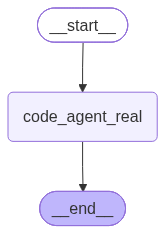

In [4]:
def code_agent_real(state: DevWorkflowState) -> dict:
    prompt = state.get("review_feedback") or state["requirement"]
    result = call_claude_cli(prompt, state.get("cli_session_id"))
    return {
        "code_changes": result["result"],
        "cli_session_id": result["session_id"],
        "round": state.get("round", 0) + 1,
    }


builder = StateGraph(DevWorkflowState)
builder.add_node("code_agent_real", code_agent_real)
builder.add_edge(START, "code_agent_real")
builder.add_edge("code_agent_real", END)
graph = builder.compile()
show_graph(graph)

## 跑第一輪：真的呼叫一次 `claude`

刻意要求純文字回答、不要真的寫程式碼、不要用任何工具——這份 demo 只驗證「LangGraph node
包一層 subprocess 呼叫 CLI，資訊進出對不對」，不驗證工具呼叫路徑。

In [5]:
requirement = (
    "你是模擬中的 coding agent。用一句話（繁體中文）描述你打算怎麼幫一個 Flask app "
    "加上一個 /health 健康檢查端點的計畫，不要真的寫程式碼，只講計畫本身。"
)

round1 = graph.invoke({"requirement": requirement, "review_feedback": "", "round": 0})
print("第一輪 code_changes：", round1["code_changes"])
print("cli_session_id：", round1["cli_session_id"])

第一輪 code_changes： 我會在現有 Flask app 中新增一個 `/health` 路由（GET，回傳簡單 JSON 如 `{"status": "ok"}` 及 200 狀態碼），並依 NPSPO Flask 慣例掛在 app factory（`create_app()`）建立的 blueprint 或直接註冊在 app 上，不接資料庫查詢等額外邏輯，純粹用來讓 uptime/監控工具檢查服務是否存活。
cli_session_id： d7880237-259b-4853-b2c0-3fd3094e98b1


## 跑第二輪：只給 review 意見，靠 `--resume` 接續上一輪

`review_feedback` 完全沒有提到第一輪的計畫內容是什麼——如果 `claude` 真的透過 `--resume`
記得上一輪，它應該答得出「根據你之前講的計畫」，補上測試方式；如果沒有真的記得，它會答非所問
（不知道在補充什麼計畫的測試方式）。

In [6]:
review_feedback = "review 覺得你剛剛的計畫沒有提到怎麼測試這個端點，請針對這點補充，並在回覆裡簡短提一下你上一輪的計畫是什麼以證明你記得。"

round2 = graph.invoke({
    **round1,
    "review_feedback": review_feedback,
})
print("第二輪 code_changes：", round2["code_changes"])
print("cli_session_id 是否跟第一輪一致：", round2["cli_session_id"] == round1["cli_session_id"])

第二輪 code_changes： 上一輪的計畫是：在現有 Flask app 中新增一個 `/health` 路由，回傳簡單 JSON `{"status": "ok"}` 與 200 狀態碼，掛在 app factory（`create_app()`）建立的地方，不接資料庫等額外邏輯，純粹給監控用。

補充測試部分：會用 Flask 內建的 `test_client()` 寫一個簡單測試（例如 `client.get("/health")`），驗證回傳狀態碼是 200、且 JSON body 符合預期格式，作為這個端點的驗證方式。
cli_session_id 是否跟第一輪一致： True


## 驗證結果

不是只憑肉眼看第二輪回答「感覺有記得」——這裡做兩個機械檢查：
1. `session_id` 兩輪一致（跟 `labs/` 那次實驗一樣的觀察）
2. 第二輪的回答有沒有真的提到「測試」這個字——這是 `review_feedback` 明確要求補的內容，
   如果 CLI 真的記得上下文並照做，回答裡應該會出現。

In [7]:
assert round2["cli_session_id"] == round1["cli_session_id"], "session_id 在兩輪之間變了，resume 沒有生效"
assert "測試" in round2["code_changes"] or "test" in round2["code_changes"].lower(), (
    "第二輪回答沒有提到測試，可能沒有正確接住 review_feedback 的要求"
)
print("驗證通過：session_id 一致、第二輪確實回應了 review 的補充要求。")

total_cost = 0.0
for r in (round1, round2):
    pass  # code_changes 只留了 result 文字，完整 JSON（含 total_cost_usd）沒有存進 state
print("（這次 demo 沒有把每輪的 total_cost_usd 存進 state，只在 call_claude_cli 回傳的原始 dict 裡；"
      "正式接線時建議連同 usage/cost 一起存進 state 或 report_progress，方便追蹤真實花費。）")

驗證通過：session_id 一致、第二輪確實回應了 review 的補充要求。
（這次 demo 沒有把每輪的 total_cost_usd 存進 state，只在 call_claude_cli 回傳的原始 dict 裡；正式接線時建議連同 usage/cost 一起存進 state 或 report_progress，方便追蹤真實花費。）


## 這份 demo 證明了什麼、還沒證明什麼

**證明了（這次真的執行、真的檢查過）**：
- LangGraph node 裡用 `subprocess.run(["claude", "-p", ...])` 真的可以驅動 CLI，不用另外
  處理 API key。
- `cli_session_id` 存在 state 裡、下一輪從 state 讀出來傳給 `--resume`，這個「LangGraph
  state 當作 CLI session 的定位資訊」的設計是通的。
- 第二輪只給零散的 review 意見（不重複原始需求），CLI 仍然給出跟第一輪計畫相關、有針對性
  的回答——不是靠 prompt 裡塞更多文字硬湊出來的，是真的靠 `--resume` 接住的上下文。

**還沒證明（下一步該做的事，這裡故意留白）**：
- 真正的 `code_agent` 需要讀寫檔案、跑指令——這份 demo 完全沒有測工具呼叫路徑跟對應的
  `--allowedTools`/`--restricted`/`--permission-mode` 權限控制。
- 沒有測 `--json-schema` 強制結構化輸出，`synthesize_verdict` 這類需要乾淨欄位的節點
  還需要另外驗證。
- 沒有測失敗情境（CLI 逾時、`is_error: true`、`--max-budget-usd` 真的觸發上限時
  `code_agent` 該怎麼處理，目前只是讓例外往外拋，正式接線需要接進 `review_gate`/重試邏輯）。
- 政策/合規問題還是沒有解決——這份 demo 只補強了「技術上真的能動」這一點的證據，不代表可以
  直接規模化到部門正式基礎設施。